<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/A0_002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

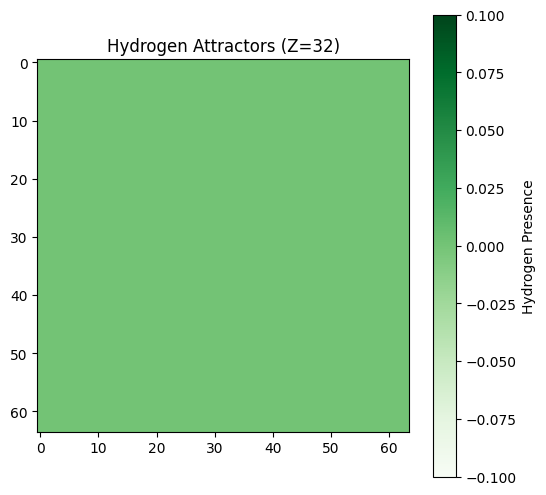

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

# --- Parameters ---
N = 64          # Lattice size (can scale to 100, 128, etc.)
T = 500         # Time steps
p_seed = 0.01   # Initial attractor seed probability
bond_threshold = 0.01  # Gradient threshold for bonding

# --- Initialization ---
field = np.random.rand(N, N, N)
attractors = np.random.rand(N, N, N) < p_seed

# --- Update Rule: Entropic Smoothing + Bonding ---
def update(field, attractors):
    kernel = np.ones((3, 3, 3)) / 27
    local_avg = convolve(field, kernel, mode='wrap')
    delta = local_avg - field
    field += 0.1 * delta  # Smoothing step
    grad = np.abs(delta)
    attractors |= (grad < bond_threshold)  # Bonding condition
    return field, attractors

# --- Simulation Loop ---
history = []
for t in range(T):
    field, attractors = update(field, attractors)
    if t % 50 == 0:
        history.append(attractors.copy())

# --- Bond Map: Count Neighbors for Each Attractor ---
def bond_map(attractors):
    kernel = np.ones((3, 3, 3))
    bonds = convolve(attractors.astype(int), kernel, mode='wrap') - 1
    return bonds

# --- Hydrogen Detection: Single-Bonded Attractors ---
def detect_hydrogen(bonds):
    hydrogen = (bonds == 1)
    return hydrogen

# --- Visualization: Hydrogen Slice ---
def plot_hydrogen(hydrogen, z_slice):
    plt.figure(figsize=(6,6))
    plt.imshow(hydrogen[:, :, z_slice], cmap='Greens')
    plt.title(f"Hydrogen Attractors (Z={z_slice})")
    plt.colorbar(label='Hydrogen Presence')
    plt.show()

# --- Run Scanner ---
bonds = bond_map(attractors)
hydrogen = detect_hydrogen(bonds)
plot_hydrogen(hydrogen, N//2)
